# U.S. Medical Insurance Costs

In [3]:
# Data Observations: No Missing Values, seven different variables, some are numerical and some are categorical
    # BMI is included within this database although it may not actually be a significant indicator of a person's health

In [5]:
# Project Goals
    # Identify the average age of patients in the dataset
    # Observe where the highest frequency of observations are located
    # Identify the effect gender has on insurance costs

In [9]:
# import necessary
import csv

In [11]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('insurance.csv')

# View the first 5 rows (default)
print(df.head())

# Or view a custom number of rows, like 10
print(df.head(10))


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no 

In [13]:
# Check all the column names
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [15]:
# Saving columns as variables in python
ages = df['age']
sexes = df['sex']
bmis = df['bmi']
children = df['children']
smoker_status = df['smoker']
regions = df['region']
charges = df['charges']

In [28]:
# Importing for visuals and statistical modelling
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [50]:
# Identifying the average age of patients
average_age = df['age'].mean()
print(f"Average age of patients: {average_age:.2f}")

# Count the number of observations for each gender
gender_counts = df['sex'].value_counts()

# Display the counts
print(gender_counts)

Average age of patients: 39.21
sex
male      676
female    662
Name: count, dtype: int64


Frequency of observations by region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


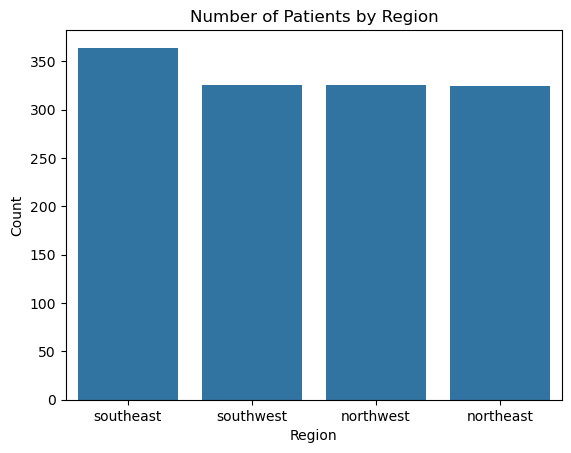

In [52]:
# Identify the frequency of observations within each region
region_counts = df['region'].value_counts()
print("Frequency of observations by region:")
print(region_counts)

# Visualize data
sns.countplot(data=df, x='region', order=region_counts.index)
plt.title("Number of Patients by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

Average insurance charges by gender:
sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64


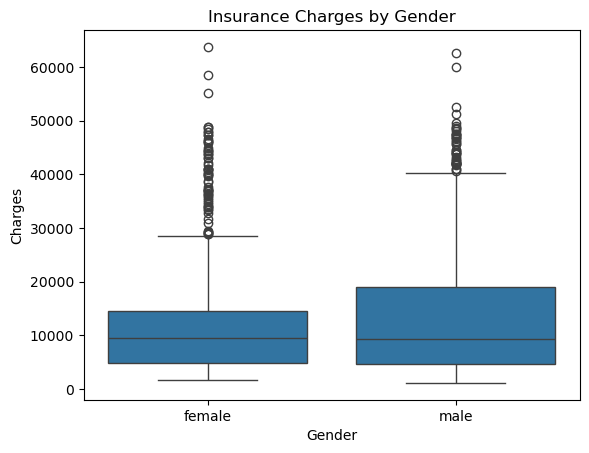

In [54]:
# View the different averages of charges by gender
gender_avg_charges = df.groupby('sex')['charges'].mean()
print("Average insurance charges by gender:")
print(gender_avg_charges)

# Visualize data
sns.boxplot(data=df, x='sex', y='charges')
plt.title("Insurance Charges by Gender")
plt.xlabel("Gender")
plt.ylabel("Charges")
plt.show()

In [56]:
df = pd.read_csv('insurance.csv')

# Convert 'sex' to a numeric variable using one-hot encoding (male = 1, female = 0)
df['sex_binary'] = df['sex'].apply(lambda x: 1 if x == 'male' else 0)

# Define the independent variable (X) and dependent variable (y)
X = df['sex_binary']
y = df['charges']

# Add a constant to X for the intercept
X = sm.add_constant(X)

In [32]:
# Create and fit the model
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.400
Date:                Mon, 14 Apr 2025   Prob (F-statistic):             0.0361
Time:                        11:21:19   Log-Likelihood:                -14475.
No. Observations:                1338   AIC:                         2.895e+04
Df Residuals:                    1336   BIC:                         2.897e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.257e+04    470.072     26.740      0.0

In [ ]:
# Regression Results: The p value identifies that the relationship between gender and insurance charges is statistically significant.
    # The average difference in charges between men and women is $ 1,387. With men on average having higher charges than women. 

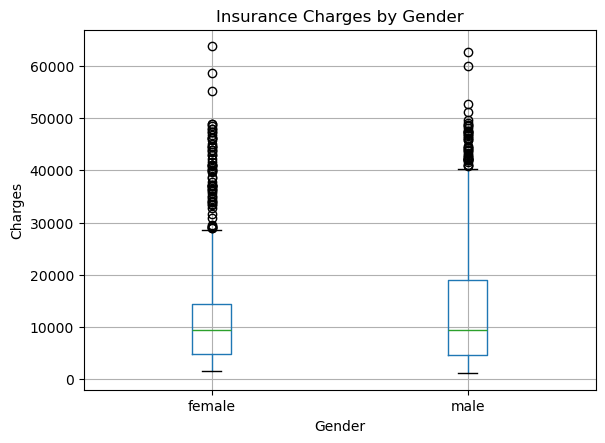

In [34]:
# Plotting charges by gender
df.boxplot(column='charges', by='sex')
plt.title("Insurance Charges by Gender")
plt.suptitle("")  # Remove the default title
plt.xlabel("Gender")
plt.ylabel("Charges")
plt.show()

In [ ]:
""" That is my completed project examining the different patterns within this dataset representing insurance costs for a large group of patients.
    I specifically wanted to focus on differences between genders, due to the societal expectation of women to have children which may affect their insurance costs.
    This analysis has identified that men are likely to have higher costs of insurance within this dataset.
    Gender may be statistically significant although all of these demographic variables have their own affects that influence the insurance charges that are made. 
